# Video 8: Molecular Generation and Lead Optimization
### AI for Drug Discovery Series - DigitalSreeni

In Video 7 we scored our twenty EGFR hits through five ADMET models. Our best compound CHEMBL382797 scored 7 out of 10. The limiting factors were elevated ClinTox risk and Tox21 toxicity signals. No compound reached the advancement threshold of 8.

In this notebook we ask a different question: instead of ranking compounds we already have, can we generate new ones that are better?

We use two complementary approaches, both applied to the same lead compound:

**Part A -- Scaffold Decoration**: Keep the molecular scaffold that drives EGFR potency. Systematically replace one substituent with fragments curated for specific ADMET improvements. Every generated molecule has a clear structural rationale. This mirrors how medicinal chemists think about lead optimization.

**Part B -- SelfiesGPT**: Train a small transformer language model on 1,400+ real EGFR inhibitors from ChEMBL. Prime it with the beginning of our best hit and let it propose novel molecules from the learned chemical space. This is the generative AI approach.

The two approaches are complementary: scaffold decoration gives interpretable, chemist-guided proposals; the language model gives structurally diverse, data-driven proposals. Together they cover both ends of the lead optimization strategy space.

**Why SELFIES for the language model?**
SMILES is the standard way chemists write molecules, but it is difficult for language models -- the grammar is complex and a single wrong character invalidates the whole string. A character-level SMILES model typically achieves only 10-30% validity. SELFIES (Self-Referencing Embedded Strings) was designed to solve this: every SELFIES string, no matter how it is constructed, decodes to a chemically valid molecule. Validity by construction, not by learning.

**Requirements**: GPU runtime for Part B (Runtime > Change runtime type > T4 GPU)

In [ ]:
import subprocess, sys, os, json, time, math, urllib.request
from pathlib import Path

def install(pkg, label):
    print(f'Installing {label}...', end=' ', flush=True)
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'],
                       capture_output=True, text=True)
    print('done' if r.returncode == 0 else 'FAILED')

install('rdkit',   'RDKit')
install('selfies', 'SELFIES')
install('xgboost', 'XGBoost')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Draw
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.rdMolDescriptors import CalcTPSA
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.rdmolops import ReplaceSubstructs
RDLogger.DisableLog('rdApp.*')

import selfies as sf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import xgboost as xgb

Path('results').mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'RDKit   {Chem.rdBase.rdkitVersion}')
print(f'SELFIES {sf.__version__}')
print(f'PyTorch {torch.__version__}')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}  '
          f'({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)')


Installing RDKit... done
Installing SELFIES... done
Installing XGBoost... done
RDKit   2026.03.2
SELFIES 2.1.1
PyTorch 2.10.0+cu128
Device: cuda
GPU: Tesla T4  (15.6 GB)


## Part 0: Our Starting Points

We define our three best hits from the Video 7 ADMET dashboard and visualize them before we begin generating anything. These are our leads -- the compounds we are trying to improve upon.

Lead compounds for optimization:


,compound_id,admet_score,notes
0,CHEMBL382797,7,Strongest BBB exclusion. Moderate ClinTox. Cle...
1,CHEMBL13462,7,Best Tox21 profile. Moderate ClinTox (0.61).
2,CHEMBL112582,7,Lowest ClinTox of the three (0.17). Moderate s...


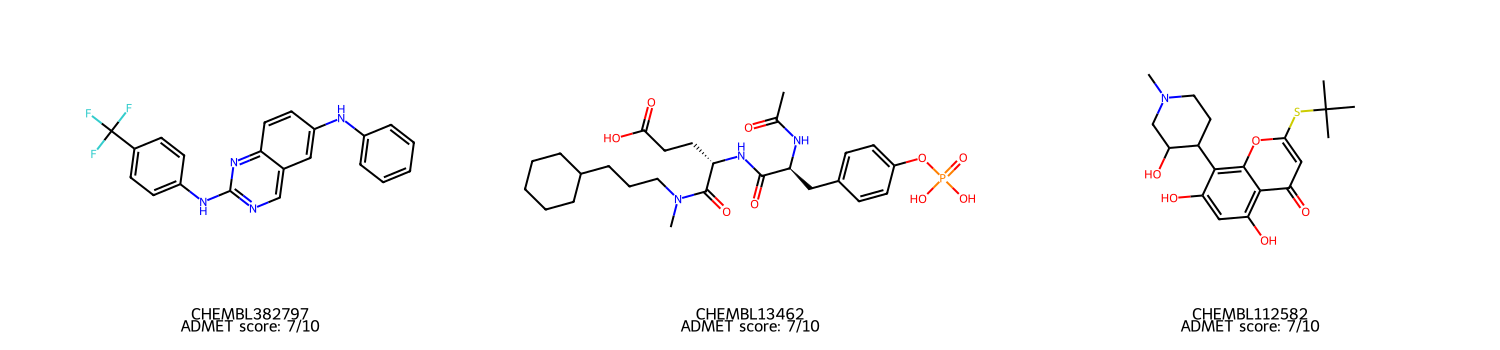

In [ ]:
# Top 3 EGFR hits from the Video 7 ADMET dashboard
leads = pd.DataFrame([
    {
        "compound_id": "CHEMBL382797",
        "smiles":      "FC(F)(F)c1ccc(Nc2ncc3cc(Nc4ccccc4)ccc3n2)cc1",
        "admet_score": 7,
        "notes":       "Strongest BBB exclusion. Moderate ClinTox. Clean Tox21 profile.",
        "fix_target":  "Reduce ClinTox risk. Improve Tox21 score.",
    },
    {
        "compound_id": "CHEMBL13462",
        "smiles":      "CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@H](CCC(=O)O)C(=O)N(C)CCCC1CCCCC1",
        "admet_score": 7,
        "notes":       "Best Tox21 profile. Moderate ClinTox (0.61).",
        "fix_target":  "Reduce ClinTox risk.",
    },
    {
        "compound_id": "CHEMBL112582",
        "smiles":      "CN1CCC(c2c(O)cc(O)c3c(=O)cc(SC(C)(C)C)oc23)C(O)C1",
        "admet_score": 7,
        "notes":       "Lowest ClinTox of the three (0.17). Moderate solubility.",
        "fix_target":  "Improve solubility. Maintain low toxicity.",
    },
])

print("Lead compounds for optimization:")
display(leads[["compound_id", "admet_score", "notes"]])

mols   = [Chem.MolFromSmiles(s) for s in leads["smiles"]]
labels = [f'{row.compound_id}\nADMET score: {row.admet_score}/10'
          for row in leads.itertuples()]
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(500, 350),
                           legends=labels, returnPNG=False)
img.save('results/lead_compounds.png')
img


## Part A: Scaffold Decoration

### What is scaffold decoration?

Every drug molecule can be thought of as having two components:

- The **scaffold** -- the rigid ring system and linkers that form the core. This is assumed to drive the binding interaction with the target protein. In kinase inhibitors, the scaffold typically sits in the ATP binding pocket and makes key hydrogen bonds with the hinge region.

- The **R-groups** -- the substituents hanging off the scaffold. These peripheral groups influence pharmacokinetic and toxicity properties without dramatically changing how the molecule binds.

Scaffold decoration is the strategy of keeping the core intact (preserving potency) while systematically replacing R-groups (improving ADMET). This is one of the most common strategies in real medicinal chemistry campaigns.

### Our strategy

We focus on CHEMBL382797, our best overall hit. Its scaffold is a diaminoquinazoline with a trifluoromethylphenyl group on one nitrogen. The terminal aniline phenyl group on the other nitrogen is the R-group we will modify -- it is peripheral to the binding pharmacophore and its electronic and steric properties directly influence lipophilicity, ClinTox risk, and toxicity flags.

Lead SMILES:     FC(F)(F)c1ccc(Nc2ncc3cc(Nc4ccccc4)ccc3n2)cc1
Scaffold SMILES: c1ccc(Nc2ccc3nc(Nc4ccccc4)ncc3c2)cc1

The Murcko scaffold is the ring system and linkers that define the core.
The two NH groups are attachment points for the R-groups we will modify.


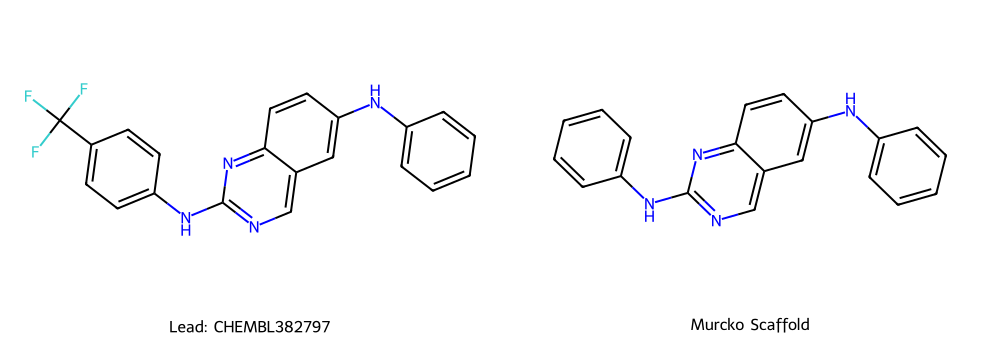

In [ ]:
LEAD_SMILES = "FC(F)(F)c1ccc(Nc2ncc3cc(Nc4ccccc4)ccc3n2)cc1"
LEAD_ID    = "CHEMBL382797"

lead_mol   = Chem.MolFromSmiles(LEAD_SMILES)
scaffold   = MurckoScaffold.GetScaffoldForMol(lead_mol)

print(f"Lead SMILES:     {LEAD_SMILES}")
print(f"Scaffold SMILES: {Chem.MolToSmiles(scaffold)}")
print()
print("The Murcko scaffold is the ring system and linkers that define the core.")
print("The two NH groups are attachment points for the R-groups we will modify.")

# Show lead and scaffold side by side
img = Draw.MolsToGridImage(
    [lead_mol, scaffold], molsPerRow=2, subImgSize=(500, 350),
    legends=[f'Lead: {LEAD_ID}', 'Murcko Scaffold'],
    returnPNG=False
)
img.save('results/scaffold.png')
img


In [ ]:
# Curated fragment library for scaffold decoration
# Each entry is an aniline SMILES (N attached to the replacement ring)
# that replaces the terminal aniline group on the quinazoline scaffold.
# Every fragment is chosen for a specific ADMET rationale.

FRAGMENT_LIBRARY = {
    "solubility_improvers": [
        ("Nc1ccc(O)cc1",          "para-hydroxyphenyl -- H-bond donor, improves solubility"),
        ("Nc1ccc(C(=O)O)cc1",     "para-carboxyphenyl -- ionizable at physiological pH"),
        ("Nc1ccc(OC)cc1",         "para-methoxyphenyl -- moderate polarity increase"),
        ("Nc1ccc(F)cc1",          "para-fluorophenyl -- bioisostere, moderate polarity"),
        ("Nc1ccncc1",             "pyridin-4-yl -- basic N improves aqueous solubility"),
        ("Nc1cccc(O)c1",          "meta-hydroxyphenyl -- H-bond donor"),
        ("Nc1ccc(CN)cc1",         "para-aminomethylphenyl -- protonatable amine at gut pH"),
        ("Nc1ccc(NC(=O)C)cc1",    "para-acetamidophenyl -- reduces lipophilicity vs aniline"),
    ],
    "bbb_reducers": [
        ("Nc1ccc(S(=O)(=O)N)cc1", "para-sulfonamide -- high polarity, strong BBB barrier"),
        ("Nc1ccc(C(=O)N)cc1",     "para-carboxamide -- polar H-bond donor and acceptor"),
        ("Nc1cnccn1",             "pyrimidine -- two basic nitrogens, very polar"),
    ],
    "reduced_toxicity_alert": [
        ("Nc1ccc(Cl)cc1",         "para-chlorophenyl -- replaces electron-rich aniline"),
        ("Nc1ccc(C#N)cc1",        "para-cyanophenyl -- withdraws electrons, reduces alert"),
        ("Nc1ccc(OC(F)(F)F)cc1",  "para-OCF3-phenyl -- metabolically stable bioisostere"),
        ("Nc1ccc(NC(=O)C)cc1",    "para-acetamido -- caps aniline NH2 structural alert"),
    ],
}

all_frags = [(smi, label, cat)
             for cat, frags in FRAGMENT_LIBRARY.items()
             for smi, label in frags]

# Validate
valid_frags = []
for smi, label, cat in all_frags:
    if Chem.MolFromSmiles(smi):
        valid_frags.append((smi, label, cat))
    else:
        print(f"  Invalid: {smi}")

print("Fragment library:")
for cat, frags in FRAGMENT_LIBRARY.items():
    print(f"  {cat}: {len(frags)} fragments")
print(f"  Total: {len(all_frags)} | Valid: {len(valid_frags)}")


Fragment library:
  solubility_improvers: 8 fragments
  bbb_reducers: 3 fragments
  reduced_toxicity_alert: 4 fragments
  Total: 15 | Valid: 15


In [ ]:
def lipinski_pass(mol):
    if mol is None:
        return False
    return (Descriptors.MolWt(mol)       <= 600 and
            Descriptors.MolLogP(mol)     <=   6 and
            Descriptors.NumHDonors(mol)  <=   5 and
            Descriptors.NumHAcceptors(mol) <= 12)

def smiles_to_fp(smiles, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    return np.array(gen.GetFingerprint(mol))

# RDKit ReplaceSubstructs: find the N-phenyl bond and replace the phenyl ring
# Pattern: [NH] attached to an unsubstituted phenyl ring
patt = Chem.MolFromSmarts("[NH]-c1ccccc1")
print(f"Pattern [NH]-phenyl matches in lead: "
      f"{len(lead_mol.GetSubstructMatches(patt))} sites")

generated_a = []
seen = {Chem.MolToSmiles(lead_mol)}

for frag_smi, frag_label, frag_cat in valid_frags:
    repl_mol = Chem.MolFromSmiles(frag_smi)
    if repl_mol is None:
        continue
    results = ReplaceSubstructs(lead_mol, patt, repl_mol, replaceAll=False)
    for r in results:
        smi = Chem.MolToSmiles(r)
        # Keep only connected molecules that still contain the CF3 arm
        if "." in smi:
            continue
        if "C(F)(F)F" not in smi and "FC(F)(F)" not in smi:
            continue
        mol = Chem.MolFromSmiles(smi)
        if mol is None or not lipinski_pass(mol):
            continue
        if smi in seen:
            continue
        seen.add(smi)
        generated_a.append({
            "smiles":        smi,
            "parent":        LEAD_ID,
            "fragment":      frag_smi,
            "fragment_desc": frag_label,
            "category":      frag_cat,
            "method":        "scaffold_decoration",
        })
        break   # one valid result per fragment

df_decorated = pd.DataFrame(generated_a)
print(f"Generated {len(df_decorated)} unique decorated molecules")
print()
display(df_decorated[["smiles", "category", "fragment_desc"]])


Pattern [NH]-phenyl matches in lead: 3 sites
Generated 8 unique decorated molecules



,smiles,category,fragment_desc
0,Oc1ccc(Nc2ccc3nc(Nc4ccc(C(F)(F)F)cc4)ncc3c2)cc1,solubility_improvers,"para-hydroxyphenyl -- H-bond donor, improves s..."
1,O=C(O)c1ccc(Nc2ccc3nc(Nc4ccc(C(F)(F)F)cc4)ncc3...,solubility_improvers,para-carboxyphenyl -- ionizable at physiologic...
2,FC(F)(F)c1ccc(Nc2ncc3cc(Nc4ccncc4)ccc3n2)cc1,solubility_improvers,pyridin-4-yl -- basic N improves aqueous solub...
3,Oc1cccc(Nc2ccc3nc(Nc4ccc(C(F)(F)F)cc4)ncc3c2)c1,solubility_improvers,meta-hydroxyphenyl -- H-bond donor
4,NCc1ccc(Nc2ccc3nc(Nc4ccc(C(F)(F)F)cc4)ncc3c2)cc1,solubility_improvers,para-aminomethylphenyl -- protonatable amine a...
5,NS(=O)(=O)c1ccc(Nc2ccc3nc(Nc4ccc(C(F)(F)F)cc4)...,bbb_reducers,"para-sulfonamide -- high polarity, strong BBB ..."
6,NC(=O)c1ccc(Nc2ccc3nc(Nc4ccc(C(F)(F)F)cc4)ncc3...,bbb_reducers,para-carboxamide -- polar H-bond donor and acc...
7,FC(F)(F)c1ccc(Nc2ncc3cc(Nc4cnccn4)ccc3n2)cc1,bbb_reducers,"pyrimidine -- two basic nitrogens, very polar"


Part A generated 8 decorated molecules:


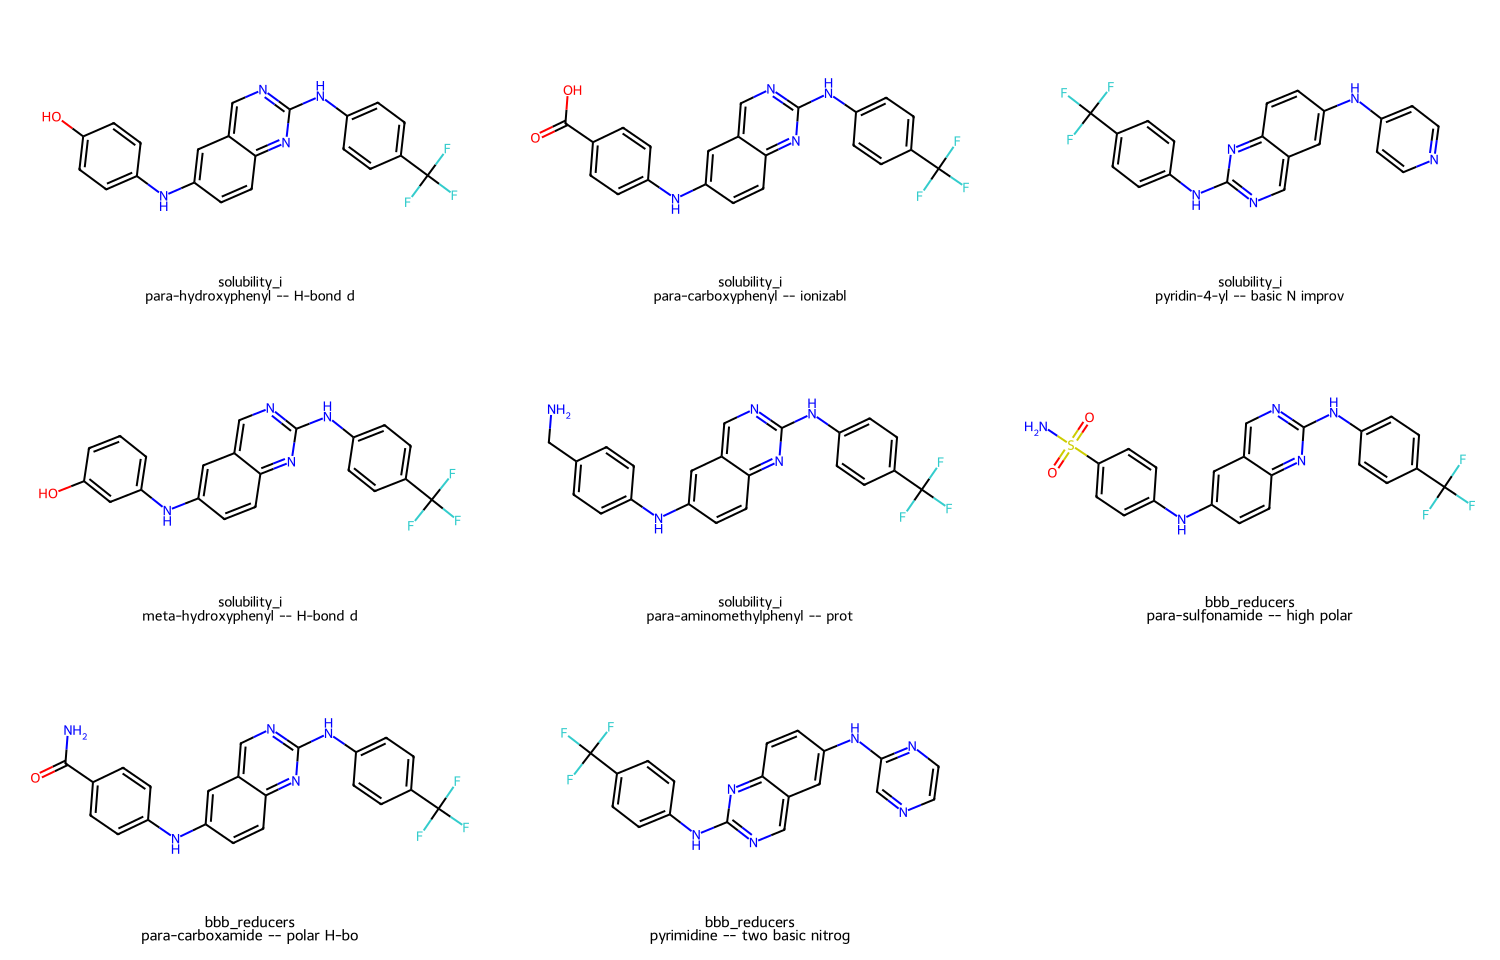

In [ ]:
if len(df_decorated) > 0:
    n_show = min(9, len(df_decorated))
    mols_dec = [Chem.MolFromSmiles(s) for s in df_decorated['smiles'][:n_show]]
    labels_dec = [f'{r.category[:12]}\n{r.fragment_desc[:30]}'
                  for r in df_decorated.head(n_show).itertuples()]
    img_dec = Draw.MolsToGridImage(
        mols_dec, molsPerRow=3, subImgSize=(500, 320),
        legends=labels_dec, returnPNG=False
    )
    img_dec.save('results/decorated_molecules.png')
    print(f"Part A generated {len(df_decorated)} decorated molecules:")
    display(img_dec)


## Part B: SelfiesGPT -- Learning to Generate EGFR Inhibitors

### The idea

Scaffold decoration is guided by chemical intuition -- we chose which fragments to try. A language model takes a different approach: it learns the statistical patterns shared by thousands of real bioactive molecules and uses that knowledge to propose new ones.

We train a small GPT (Generative Pretrained Transformer) on 1,400+ real EGFR inhibitors from ChEMBL. The model learns to predict the next token in a molecular sequence given all previous tokens. After training, we prime it with the beginning of our best hit and let it generate completions -- novel molecules that share features with the lead but explore new structural territory.

### Why SELFIES?

We represent molecules as SELFIES strings rather than SMILES. Each SELFIES token represents a complete chemical group: `[C]`, `[=C]`, `[N]`, `[Branch1]`, `[Ring1]`. Critically, the SELFIES grammar guarantees that every string decodes to a chemically valid molecule -- no matter what token sequence the model generates. This gives us 100% validity by construction, versus the 10-30% typically achieved by character-level SMILES models.

This is the same fundamental approach used in REINVENT (AstraZeneca's production molecular generation tool) -- a language model trained on molecular strings. The production version adds reinforcement learning to steer generation toward specific property targets. What we build here is the same foundation.

In [ ]:
BASE = ("https://www.ebi.ac.uk/chembl/api/data/activity"
        "?target_chembl_id=CHEMBL203&pchembl_value__gte=6"
        "&assay_type=B&limit=500&offset={offset}&format=json")

print("Fetching EGFR inhibitors from ChEMBL API...")
raw_smiles = []
for offset in [0, 500, 1000, 1500]:
    print(f'  offset {offset}...', end=' ', flush=True)
    try:
        with urllib.request.urlopen(BASE.format(offset=offset), timeout=30) as r:
            data = json.loads(r.read())
        batch = [rec['canonical_smiles'] for rec in data.get('activities', [])
                 if rec.get('canonical_smiles')]
        raw_smiles.extend(batch)
        print(f'{len(batch)} SMILES')
        time.sleep(0.5)
    except Exception as e:
        print(f'FAILED: {e}')

# Deduplicate, validate, MW filter
print("\nCleaning...")
seen, valid_smiles = set(), []
for smi in raw_smiles:
    if smi in seen:
        continue
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    canonical = Chem.MolToSmiles(mol)
    if canonical not in seen:
        mw = Descriptors.MolWt(mol)
        if 150 <= mw <= 700:
            seen.add(canonical)
            valid_smiles.append(canonical)

print(f'Unique valid SMILES (MW 150-700 Da): {len(valid_smiles)}')

# Encode to SELFIES and build vocabulary
print("Encoding to SELFIES...")
pairs = []
for smi in valid_smiles:
    try:
        enc = sf.encoder(smi)
        if enc:
            pairs.append((smi, enc))
    except Exception:
        pass

smiles_list  = [p[0] for p in pairs]
selfies_list = [p[1] for p in pairs]
print(f'Encoded: {len(pairs)}/{len(valid_smiles)}')

# Vocabulary
all_tokens = set()
for s in selfies_list:
    all_tokens.update(sf.split_selfies(s))

PAD_TOK = "[nop]"
BOS_TOK = "[BOS]"
EOS_TOK = "[EOS]"
all_tokens.discard(PAD_TOK)
vocab    = [PAD_TOK, BOS_TOK, EOS_TOK] + sorted(all_tokens)
tok2idx  = {t: i for i, t in enumerate(vocab)}
idx2tok  = {i: t for t, i in tok2idx.items()}
VOCAB_SIZE = len(vocab)
PAD_IDX    = tok2idx[PAD_TOK]
BOS_IDX    = tok2idx[BOS_TOK]
EOS_IDX    = tok2idx[EOS_TOK]

lengths = [len(list(sf.split_selfies(s))) for s in selfies_list]
MAX_LEN  = int(np.percentile(lengths, 95)) + 2

print(f'\nVocabulary: {VOCAB_SIZE} SELFIES tokens')
print(f'Max sequence length (95th pct + BOS/EOS): {MAX_LEN}')
print(f'Example: {selfies_list[0][:80]}')


Fetching EGFR inhibitors from ChEMBL API...
  offset 0... 500 SMILES
  offset 500... 500 SMILES
  offset 1000... 500 SMILES
  offset 1500... 500 SMILES

Cleaning...
Unique valid SMILES (MW 150-700 Da): 1472
Encoding to SELFIES...
Encoded: 1472/1472

Vocabulary: 45 SELFIES tokens
Max sequence length (95th pct + BOS/EOS): 70
Example: [C][C][=C][C][Branch1][C][C][=C][Branch2][Ring2][Ring2][/C][=C][\C][=Branch1][C]


In [ ]:
class SELFIESDataset(Dataset):
    """Token-level SELFIES dataset for causal language model training.

    Input:  [BOS, tok1, tok2, ..., tokN]       (all tokens except last)
    Target: [tok1, tok2, ..., tokN, EOS]       (all tokens except first)

    The model learns: given everything so far, what comes next?
    """

    def __init__(self, selfies_strings, tok2idx, max_len):
        self.data = []
        for s in selfies_strings:
            tokens  = list(sf.split_selfies(s))
            indices = ([BOS_IDX]
                       + [tok2idx.get(t, PAD_IDX) for t in tokens]
                       + [EOS_IDX])
            if len(indices) > max_len:
                continue
            indices += [PAD_IDX] * (max_len - len(indices))
            self.data.append(indices)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        t = torch.tensor(self.data[idx], dtype=torch.long)
        return t[:-1], t[1:]


train_sf, val_sf = train_test_split(selfies_list, test_size=0.1, random_state=42)
train_ds = SELFIESDataset(train_sf, tok2idx, MAX_LEN)
val_ds   = SELFIESDataset(val_sf,   tok2idx, MAX_LEN)

BATCH_SIZE   = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} sequences | Validation: {len(val_ds)} sequences')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')


Train: 1266 sequences | Validation: 143 sequences
Train batches: 10 | Val batches: 2


In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, dropout, max_len):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head   = n_head
        self.head_dim = n_embd // n_head
        self.qkv      = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.proj     = nn.Linear(n_embd, n_embd,     bias=False)
        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.tril(torch.ones(max_len, max_len)).view(1, 1, max_len, max_len)
        )

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        att = self.attn_drop(F.softmax(att, dim=-1))
        y   = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.proj(y))


class GPTBlock(nn.Module):
    def __init__(self, n_embd, n_head, ffn_mult, dropout, max_len):
        super().__init__()
        self.ln1  = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, dropout, max_len)
        self.ln2  = nn.LayerNorm(n_embd)
        self.ffn  = nn.Sequential(
            nn.Linear(n_embd, ffn_mult * n_embd),
            nn.GELU(),
            nn.Linear(ffn_mult * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


class SelfiesGPT(nn.Module):
    """SELFIES-based GPT for molecular generation.

    Architecture: token embedding + positional embedding
    -> N causal transformer blocks -> layer norm -> vocabulary logits.

    Because input and output are SELFIES tokens, every generated sequence
    is guaranteed to decode to a chemically valid molecule.
    """

    def __init__(self, vocab_size, n_embd, n_head, n_layer,
                 ffn_mult, dropout, max_len, pad_idx):
        super().__init__()
        self.max_len = max_len
        self.tok_emb = nn.Embedding(vocab_size, n_embd, padding_idx=pad_idx)
        self.pos_emb = nn.Embedding(max_len, n_embd)
        self.drop    = nn.Dropout(dropout)
        self.blocks  = nn.Sequential(
            *[GPTBlock(n_embd, n_head, ffn_mult, dropout, max_len)
              for _ in range(n_layer)]
        )
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)
        self.apply(self._init_weights)
        for name, p in self.named_parameters():
            if name.endswith('proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * n_layer))

    def _init_weights(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.zeros_(m.bias)
            nn.init.ones_(m.weight)

    def forward(self, idx):
        B, T = idx.shape
        pos  = torch.arange(T, device=idx.device).unsqueeze(0)
        x    = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        return self.head(self.ln_f(self.blocks(x)))

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.max_len:]
            logits   = self(idx_cond)[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            probs      = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            idx        = torch.cat([idx, next_token], dim=1)
            if next_token.item() == EOS_IDX:
                break
        return idx


N_EMBD = 256; N_HEAD = 4; N_LAYER = 6; FFN_MULT = 4; DROPOUT = 0.1

model = SelfiesGPT(
    vocab_size=VOCAB_SIZE, n_embd=N_EMBD, n_head=N_HEAD,
    n_layer=N_LAYER, ffn_mult=FFN_MULT, dropout=DROPOUT,
    max_len=MAX_LEN, pad_idx=PAD_IDX,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'SelfiesGPT on {device}')
print(f'  Layers: {N_LAYER} | Hidden: {N_EMBD} | Heads: {N_HEAD}')
print(f'  Vocab:  {VOCAB_SIZE} | Max len: {MAX_LEN}')
print(f'  Parameters: {n_params:,}')


SelfiesGPT on cuda
  Layers: 6 | Hidden: 256 | Heads: 4
  Vocab:  45 | Max len: 70
  Parameters: 4,773,888


Training SelfiesGPT: 40 epochs | 400 steps
Batch: 128 | LR: 0.0003 | WD: 0.1
------------------------------------------------------------
Epoch   1/40 | train=3.5530 | val=2.8542 | lr=3.00e-05
Epoch   5/40 | train=1.9799 | val=1.8889 | lr=1.50e-04
Epoch  10/40 | train=1.4740 | val=1.4118 | lr=3.00e-04
Epoch  15/40 | train=1.1588 | val=1.1180 | lr=2.81e-04
Epoch  20/40 | train=0.9595 | val=0.9420 | lr=2.27e-04
Epoch  25/40 | train=0.8304 | val=0.8282 | lr=1.55e-04
Epoch  30/40 | train=0.7456 | val=0.7697 | lr=8.25e-05
Epoch  35/40 | train=0.6958 | val=0.7466 | lr=2.94e-05
Epoch  40/40 | train=0.6778 | val=0.7330 | lr=1.00e-05
------------------------------------------------------------
Best val loss: 0.7330
Best checkpoint loaded.


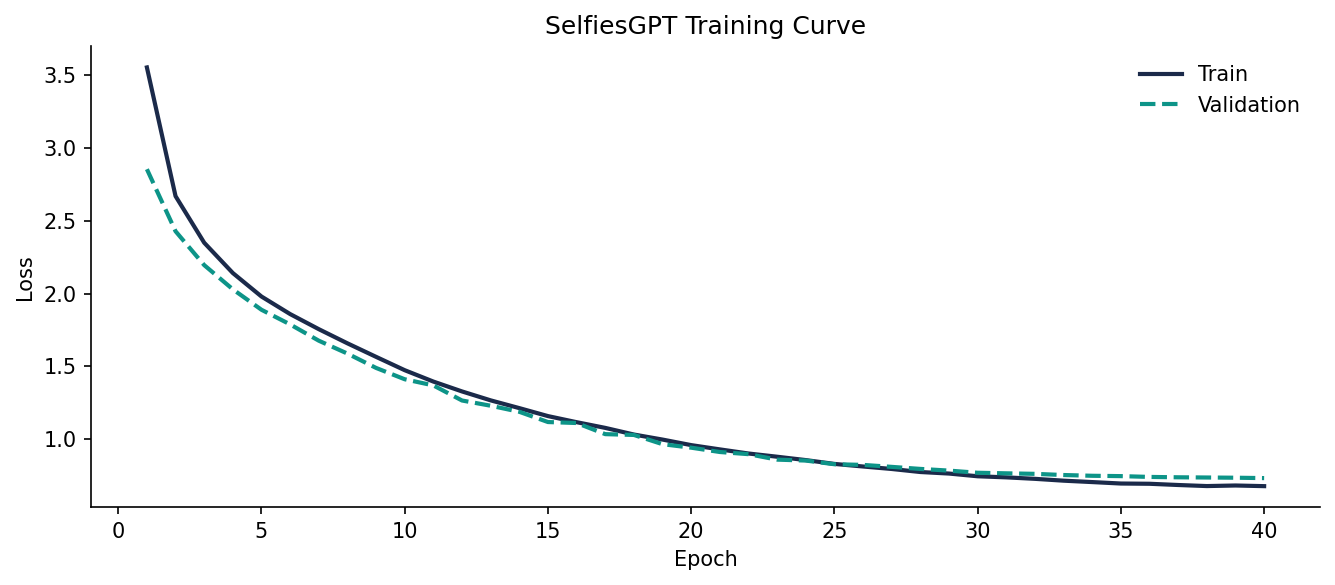

Saved: results/training_curve.png


In [ ]:
EPOCHS = 40; LR = 3e-4; WD = 0.1; WARMUP = 100

optimizer   = torch.optim.AdamW(model.parameters(), lr=LR,
                                 weight_decay=WD, betas=(0.9, 0.95))
total_steps = EPOCHS * len(train_loader)

def get_lr(step):
    if step < WARMUP:
        return LR * step / WARMUP
    p = (step - WARMUP) / (total_steps - WARMUP)
    return 1e-5 + 0.5 * (LR - 1e-5) * (1 + math.cos(math.pi * p))

train_losses, val_losses = [], []
best_val = float('inf')
step     = 0

print(f'Training SelfiesGPT: {EPOCHS} epochs | {total_steps} steps')
print(f'Batch: {BATCH_SIZE} | LR: {LR} | WD: {WD}')
print('-' * 60)

for epoch in range(1, EPOCHS + 1):
    model.train()
    ep_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        for pg in optimizer.param_groups:
            pg['lr'] = get_lr(step)
        logits = model(x)
        B, T, V = logits.shape
        loss = F.cross_entropy(logits.view(B*T, V), y.view(B*T),
                               ignore_index=PAD_IDX)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ep_loss += loss.item()
        step    += 1

    avg_train = ep_loss / len(train_loader)
    train_losses.append(avg_train)

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            lg   = model(x)
            B,T,V = lg.shape
            vl  += F.cross_entropy(lg.view(B*T,V), y.view(B*T),
                                   ignore_index=PAD_IDX).item()
    avg_val = vl / len(val_loader)
    val_losses.append(avg_val)

    if avg_val < best_val:
        best_val = avg_val
        torch.save(model.state_dict(), 'results/selfiesgpt_best.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'train={avg_train:.4f} | val={avg_val:.4f} | '
              f'lr={get_lr(step):.2e}')

print('-' * 60)
print(f'Best val loss: {best_val:.4f}')
model.load_state_dict(torch.load('results/selfiesgpt_best.pt', map_location=device))
model.eval()
print('Best checkpoint loaded.')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, EPOCHS+1), train_losses, color='#1B2A4A', lw=2, label='Train')
ax.plot(range(1, EPOCHS+1), val_losses,   color='#0D9488', lw=2,
        linestyle='--', label='Validation')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('SelfiesGPT Training Curve')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('results/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/training_curve.png')


In [ ]:
def decode_tokens(token_list):
    """Convert token index list to canonical SMILES. Returns None if invalid."""
    tokens = []
    for idx in token_list:
        if idx in (EOS_IDX, PAD_IDX):
            break
        if idx == BOS_IDX:
            continue
        tokens.append(idx2tok.get(idx, "[nop]"))
    try:
        smi = sf.decoder("".join(tokens))
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except Exception:
        return None


def generate_molecules(n_samples, temperature=1.0, top_k=20, seed_selfies=None):
    model.eval()
    train_set = set(smiles_list)
    results   = []
    with torch.no_grad():
        for _ in range(n_samples):
            if seed_selfies:
                seed_tok = list(sf.split_selfies(seed_selfies))
                prompt   = ([BOS_IDX]
                            + [tok2idx.get(t, PAD_IDX) for t in seed_tok])
            else:
                prompt = [BOS_IDX]
            idx = torch.tensor([prompt], dtype=torch.long, device=device)
            out = model.generate(idx, max_new_tokens=MAX_LEN,
                                 temperature=temperature, top_k=top_k)
            smi = decode_tokens(out[0].tolist())
            results.append({
                'smiles': smi,
                'valid':  smi is not None,
                'novel':  (smi not in train_set) if smi else False,
            })
    return pd.DataFrame(results)


# Unconditional evaluation
print('Unconditional generation (500 samples)...')
df_uncond = generate_molecules(500, temperature=1.0, top_k=20)
n_v = df_uncond['valid'].sum()
dv  = df_uncond[df_uncond['valid']]
n_u = dv['smiles'].nunique()
n_n = dv['novel'].sum()
print(f'  Validity:   {n_v/500*100:.1f}%  ({n_v}/500)')
print(f'  Uniqueness: {n_u/n_v*100:.1f}%  ({n_u}/{n_v})')
print(f'  Novelty:    {n_n/n_v*100:.1f}%  ({n_n}/{n_v})')

# Conditioned generation seeded with lead SELFIES prefix
lead_sf  = sf.encoder(LEAD_SMILES)
lead_tok = list(sf.split_selfies(lead_sf))
n_seed   = len(lead_tok) // 2
seed_sf  = "".join(lead_tok[:n_seed])

print(f'\nConditioned generation (500 samples)...')
print(f'Seed: first {n_seed}/{len(lead_tok)} SELFIES tokens of {LEAD_ID}')
df_cond = generate_molecules(500, temperature=0.8, top_k=20,
                              seed_selfies=seed_sf)
n_v2 = df_cond['valid'].sum()
df_cv = df_cond[df_cond['valid']].drop_duplicates('smiles').copy()
print(f'  Valid: {n_v2}/500 ({n_v2/500*100:.0f}%)')
print(f'  Unique valid: {len(df_cv)} | Novel: {df_cv["novel"].sum()}')


Unconditional generation (500 samples)...
  Validity:   100.0%  (500/500)
  Uniqueness: 98.0%  (490/500)
  Novelty:    95.0%  (475/500)

Conditioned generation (500 samples)...
Seed: first 23/46 SELFIES tokens of CHEMBL382797
  Valid: 500/500 (100%)
  Unique valid: 367 | Novel: 367


## Part C: Scoring All Generated Molecules Through ADMET

We now score every generated molecule from both Part A and Part B through the same five ADMET models used in Video 7. Any molecule scoring higher than the lead (ADMET score 7) is a candidate for advancement.

In [ ]:
BASE_URL = ('https://raw.githubusercontent.com/GLambard/'
            'Molecules_Dataset_Collection/master/latest/')

def featurize(df, smiles_col='smiles', label_col=None):
    fps, labels, idx = [], [], []
    for i, row in df.iterrows():
        fp = smiles_to_fp(row[smiles_col])
        if fp is not None:
            fps.append(fp); idx.append(i)
            if label_col: labels.append(row[label_col])
    return np.array(fps), (np.array(labels) if label_col else None), idx

def train_reg(Xtr, ytr):
    m = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1)
    m.fit(Xtr, ytr, verbose=False); return m

def train_clf(Xtr, ytr, spw=None):
    p = dict(n_estimators=200, max_depth=5, learning_rate=0.05,
             subsample=0.8, colsample_bytree=0.8,
             eval_metric='logloss', random_state=42, n_jobs=-1)
    if spw: p['scale_pos_weight'] = spw
    m = xgb.XGBClassifier(**p); m.fit(Xtr, ytr, verbose=False); return m

focus_eps    = ['NR-ER', 'NR-AR', 'SR-ARE', 'SR-MMP']
admet_models = {}

print('Building ADMET models...')

esol  = pd.read_csv(BASE_URL + 'ESOL_delaney-processed.csv')
lbl   = 'measured log solubility in mols per litre'
esol  = esol[['smiles', lbl]].dropna()
Xe, ye, _ = featurize(esol, label_col=lbl)
Xtr, Xte, ytr, yte = train_test_split(Xe, ye, test_size=0.2, random_state=42)
admet_models['solubility'] = train_reg(Xtr, ytr); print('  Solubility: done')

lipo = pd.read_csv(BASE_URL + 'Lipophilicity.csv')[['smiles','exp']].dropna()
lipo.columns = ['smiles','logD']
Xl, yl, _ = featurize(lipo, label_col='logD')
Xtr, Xte, ytr, yte = train_test_split(Xl, yl, test_size=0.2, random_state=42)
admet_models['lipophilicity'] = train_reg(Xtr, ytr); print('  Lipophilicity: done')

bbbp = pd.read_csv(BASE_URL + 'BBBP.csv')[['smiles','p_np']].dropna()
bbbp.columns = ['smiles','BBB']
Xb, yb, _ = featurize(bbbp, label_col='BBB')
Xtr, Xte, ytr, yte = train_test_split(Xb, yb, test_size=0.2, random_state=42, stratify=yb)
neg, pos = (ytr==0).sum(), (ytr==1).sum()
admet_models['bbb'] = train_clf(Xtr, ytr, spw=neg/pos); print('  BBB: done')

ct = pd.read_csv(BASE_URL + 'clintox.csv')[['smiles','CT_TOX']].dropna()
Xct, yct, _ = featurize(ct, label_col='CT_TOX')
Xtr, Xte, ytr, yte = train_test_split(Xct, yct, test_size=0.2,
                                       random_state=42, stratify=yct)
neg, pos = (ytr==0).sum(), (ytr==1).sum()
admet_models['clintox'] = train_clf(Xtr, ytr, spw=neg/max(pos,1))
print('  ClinTox: done')

tox21 = pd.read_csv(BASE_URL + 'tox21.csv')
tfps, tidx = [], []
for i, row in tox21.iterrows():
    fp = smiles_to_fp(str(row['smiles']))
    if fp is not None: tfps.append(fp); tidx.append(i)
Xt21   = np.array(tfps)
t21v   = tox21.loc[tidx].reset_index(drop=True)
for ep in focus_eps:
    mask = t21v[ep].notna()
    Xep  = Xt21[mask.values]
    yep  = t21v.loc[mask, ep].astype(int).values
    Xtr, Xte, ytr, yte = train_test_split(Xep, yep, test_size=0.2,
                                           random_state=42, stratify=yep)
    neg, pos = (ytr==0).sum(), (ytr==1).sum()
    admet_models[f'tox21_{ep}'] = train_clf(Xtr, ytr, spw=neg/max(pos,1))
print(f'  Tox21 (4 endpoints): done')
print(f'All {len(admet_models)} ADMET models ready.')


Building ADMET models...
  Solubility: done
  Lipophilicity: done
  BBB: done
  ClinTox: done
  Tox21 (4 endpoints): done
All 8 ADMET models ready.


In [ ]:
def score_admet(smiles, models):
    fp  = smiles_to_fp(smiles)
    mol = Chem.MolFromSmiles(smiles) if fp is not None else None
    if fp is None or mol is None:
        return None
    X = fp.reshape(1, -1)
    sol     = models['solubility'].predict(X)[0]
    logd    = models['lipophilicity'].predict(X)[0]
    bbb     = models['bbb'].predict_proba(X)[0, 1]
    ct      = models['clintox'].predict_proba(X)[0, 1]
    max_tox = max(models[f'tox21_{ep}'].predict_proba(X)[0, 1]
                  for ep in focus_eps)
    score  = 0
    score += 2 if sol >= -4      else (1 if sol >= -6      else 0)
    score += 2 if 1 <= logd <= 3 else (1 if 0 <= logd <= 5 else 0)
    score += 2 if bbb  < 0.5    else (1 if bbb  < 0.7     else 0)
    score += 2 if ct   < 0.3    else (1 if ct   < 0.5     else 0)
    score += 2 if max_tox < 0.3 else (1 if max_tox < 0.5  else 0)
    return {'admet_score': score,
            'pred_log_sol': round(sol, 3), 'pred_logD': round(logd, 3),
            'pred_BBB': round(bbb, 3), 'pred_clintox': round(ct, 3),
            'max_tox21': round(max_tox, 3),
            'MW': round(Descriptors.MolWt(mol), 1),
            'LogP': round(Descriptors.MolLogP(mol), 2)}

# Score lead
lead_s = score_admet(LEAD_SMILES, admet_models)
LEAD_ADMET = lead_s['admet_score']
print(f'Lead {LEAD_ID}: ADMET {LEAD_ADMET}/10  '
      f'(sol={lead_s["pred_log_sol"]:.3f}  logD={lead_s["pred_logD"]:.3f}  '
      f'BBB={lead_s["pred_BBB"]:.3f}  CT={lead_s["pred_clintox"]:.3f}  '
      f'Tox21={lead_s["max_tox21"]:.3f})')

# Score Part A decorated molecules
print(f'\nScoring {len(df_decorated)} scaffold-decorated molecules (Part A)...')
scored_a = []
for _, row in df_decorated.iterrows():
    s = score_admet(row['smiles'], admet_models)
    if s:
        scored_a.append({**row.to_dict(), **s})
df_sa = pd.DataFrame(scored_a).sort_values('admet_score', ascending=False)
print(f'  Best Part A score: {df_sa["admet_score"].max()}/10')
print(f'  Improved over lead (>{LEAD_ADMET}): {(df_sa["admet_score"] > LEAD_ADMET).sum()}')

# Score Part B generated molecules
print(f'\nScoring {len(df_cv)} SelfiesGPT-generated molecules (Part B)...')
scored_b = []
for _, row in df_cv.iterrows():
    s = score_admet(row['smiles'], admet_models)
    if s:
        scored_b.append({**row.to_dict(), **s})
df_sb = pd.DataFrame(scored_b).sort_values('admet_score', ascending=False)
print(f'  Best Part B score: {df_sb["admet_score"].max()}/10')
print(f'  Improved over lead (>{LEAD_ADMET}): {(df_sb["admet_score"] > LEAD_ADMET).sum()}')


Lead CHEMBL382797: ADMET 6/10  (sol=-4.138  logD=2.801  BBB=0.655  CT=0.156  Tox21=0.758)

Scoring 8 scaffold-decorated molecules (Part A)...
  Best Part A score: 8/10
  Improved over lead (>6): 8

Scoring 367 SelfiesGPT-generated molecules (Part B)...
  Best Part B score: 9/10
  Improved over lead (>6): 139


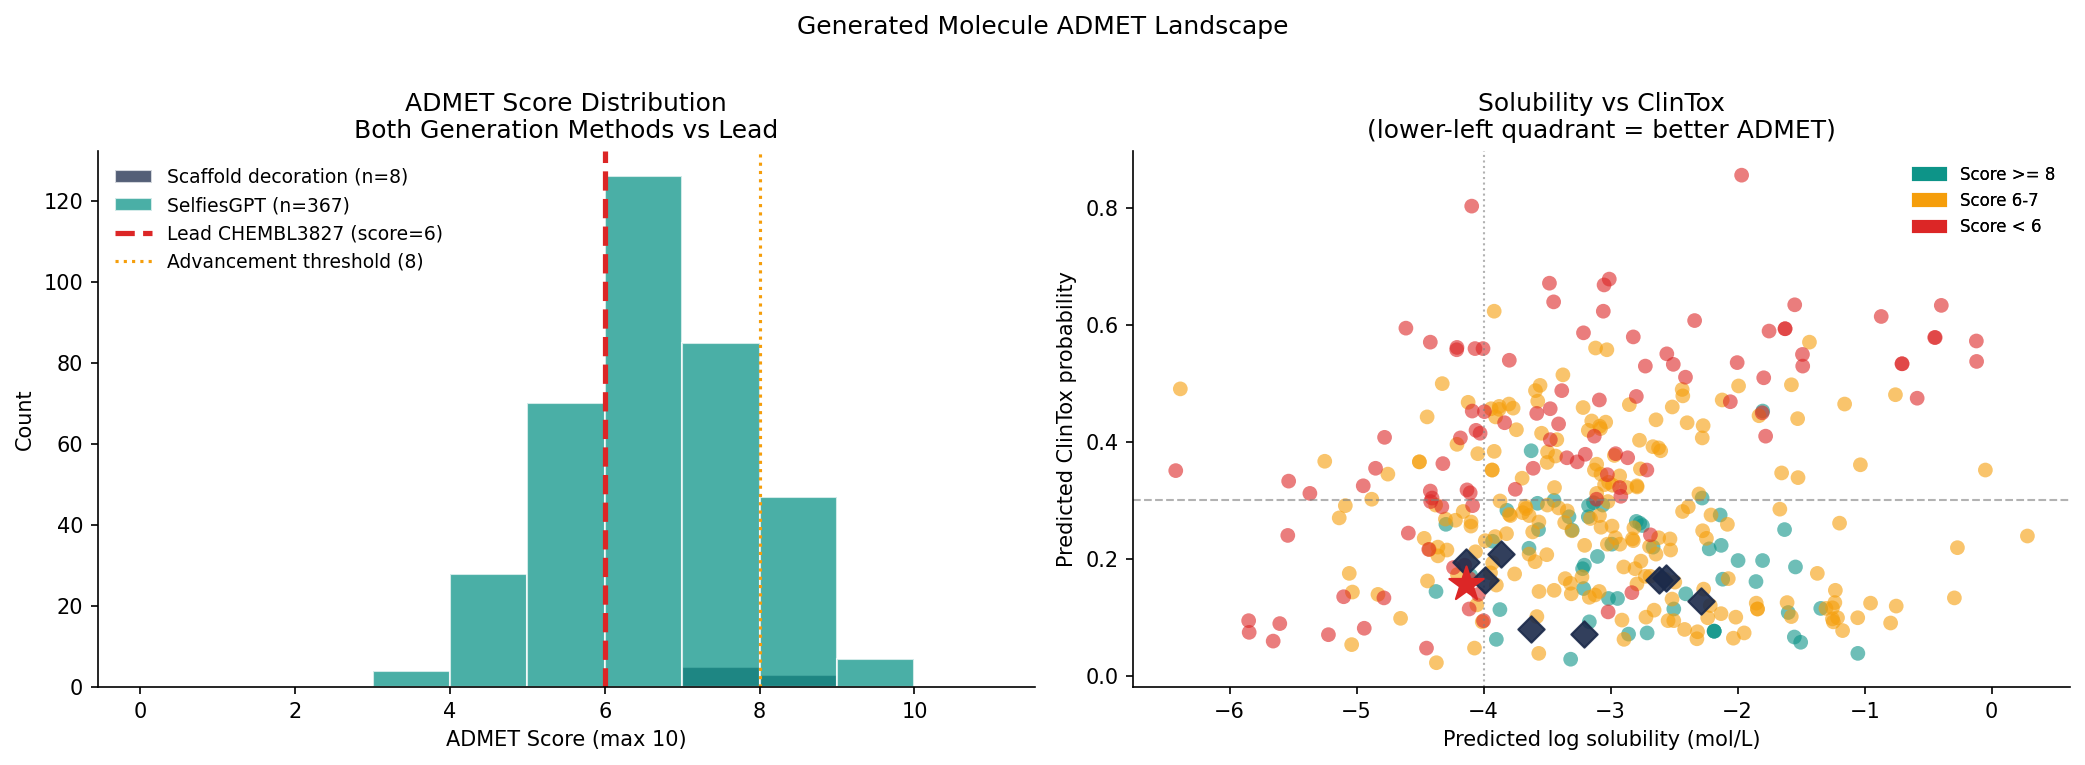

Saved: results/combined_admet_landscape.png


In [ ]:
# Combined ADMET score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = range(0, 12)
if len(df_sa) > 0:
    ax.hist(df_sa['admet_score'], bins=bins, color='#1B2A4A', alpha=0.75,
            edgecolor='white', label=f'Scaffold decoration (n={len(df_sa)})')
ax.hist(df_sb['admet_score'], bins=bins, color='#0D9488', alpha=0.75,
        edgecolor='white', label=f'SelfiesGPT (n={len(df_sb)})')
ax.axvline(LEAD_ADMET, color='#DC2626', linewidth=2.5, linestyle='--',
           label=f'Lead {LEAD_ID[:10]} (score={LEAD_ADMET})')
ax.axvline(8, color='#F59E0B', linewidth=1.5, linestyle=':',
           label='Advancement threshold (8)')
ax.set_xlabel('ADMET Score (max 10)')
ax.set_ylabel('Count')
ax.set_title('ADMET Score Distribution\nBoth Generation Methods vs Lead')
ax.legend(frameon=False, fontsize=9)

# ClinTox vs solubility scatter for Part B (more molecules)
ax2 = axes[1]
colors = ['#0D9488' if s >= 8 else '#F59E0B' if s >= 6 else '#DC2626'
          for s in df_sb['admet_score']]
ax2.scatter(df_sb['pred_log_sol'], df_sb['pred_clintox'],
            c=colors, alpha=0.6, s=50, edgecolors='none',
            label='SelfiesGPT generated')
if len(df_sa) > 0:
    ax2.scatter(df_sa['pred_log_sol'], df_sa['pred_clintox'],
                color='#1B2A4A', s=80, marker='D', alpha=0.9, zorder=4,
                label='Scaffold decorated')
ax2.scatter(lead_s['pred_log_sol'], lead_s['pred_clintox'],
            color='#DC2626', s=300, marker='*', zorder=5, label=f'Lead ({LEAD_ID[:10]})')
ax2.axhline(0.3, color='gray', linestyle='--', lw=1, alpha=0.6)
ax2.axvline(-4,  color='gray', linestyle=':',  lw=1, alpha=0.6)
ax2.set_xlabel('Predicted log solubility (mol/L)')
ax2.set_ylabel('Predicted ClinTox probability')
ax2.set_title('Solubility vs ClinTox\n(lower-left quadrant = better ADMET)')
ax2.legend(frameon=False, fontsize=9)

patches = [mpatches.Patch(color='#0D9488', label='Score >= 8'),
           mpatches.Patch(color='#F59E0B', label='Score 6-7'),
           mpatches.Patch(color='#DC2626', label='Score < 6')]
legend2  = ax2.legend(handles=patches, fontsize=8, frameon=False, loc='upper right')
ax2.add_artist(legend2)

fig.suptitle('Generated Molecule ADMET Landscape', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('results/combined_admet_landscape.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/combined_admet_landscape.png')


Top SelfiesGPT generated molecules (Part B):


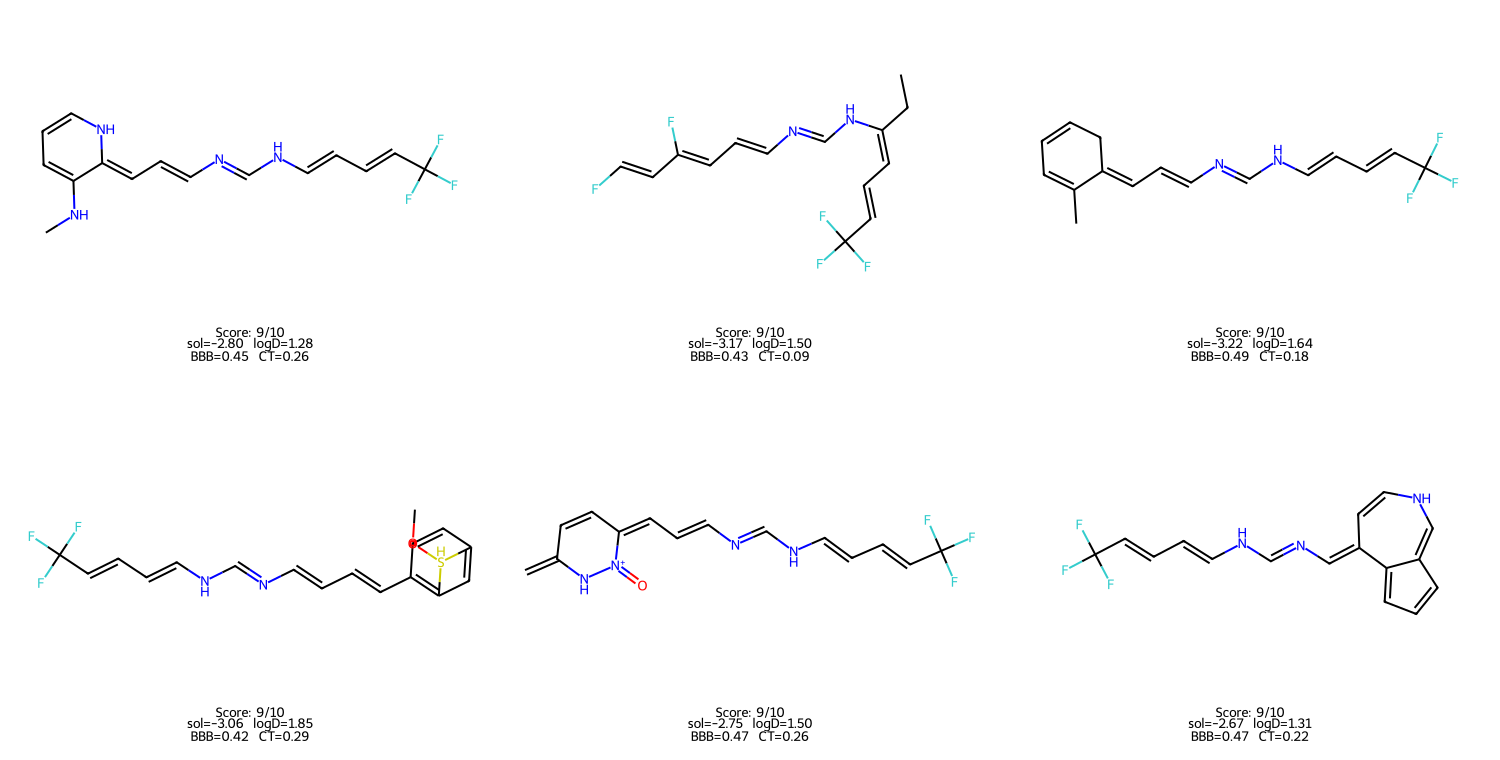


Top scaffold-decorated molecules (Part A):


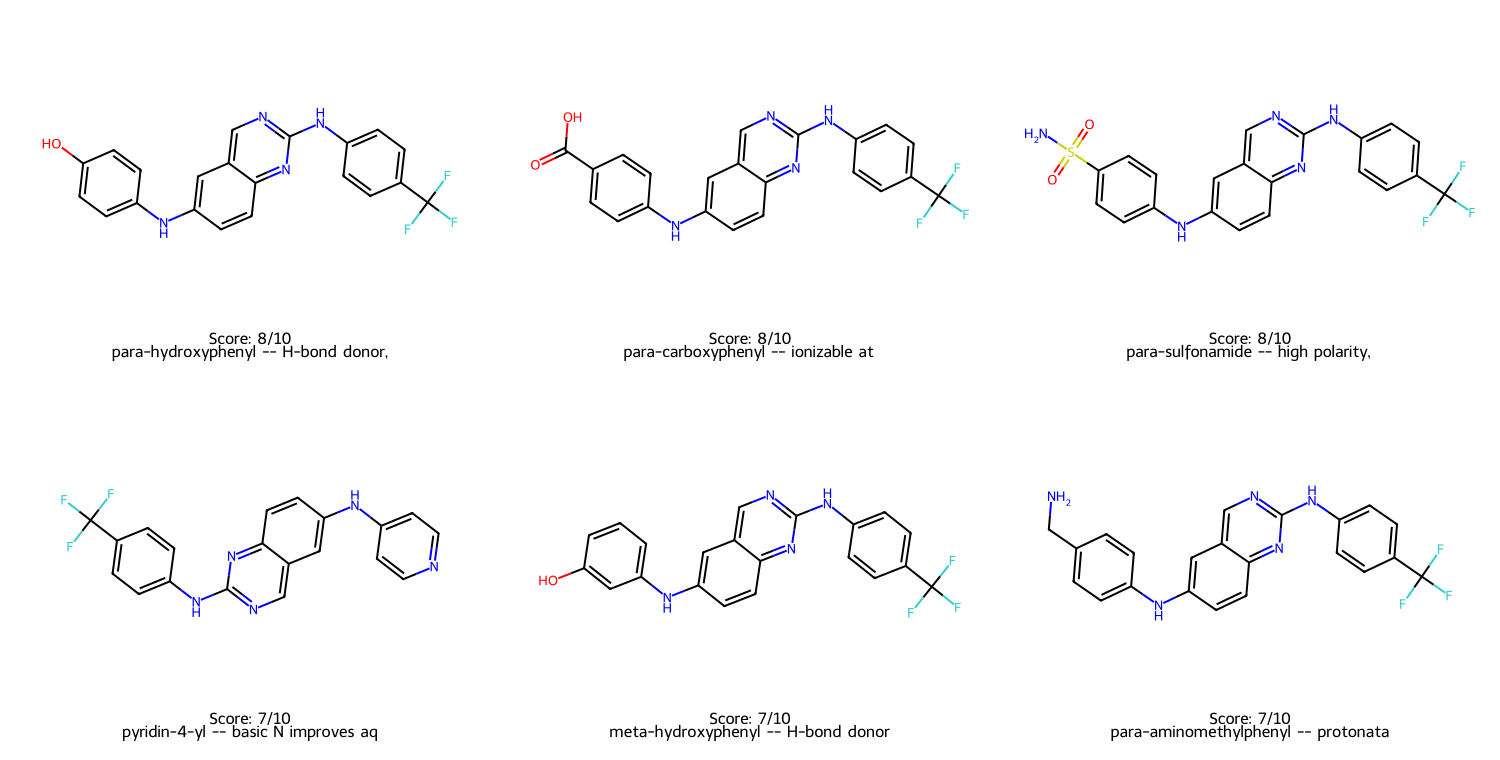

In [ ]:
# Top candidates from Part B (SelfiesGPT) -- enough molecules to show
top_b = df_sb.drop_duplicates('smiles').head(6)
mols_b = [Chem.MolFromSmiles(s) for s in top_b['smiles']]
lbls_b = [f'Score: {r.admet_score}/10\n'
           f'sol={r.pred_log_sol:.2f}  logD={r.pred_logD:.2f}\n'
           f'BBB={r.pred_BBB:.2f}  CT={r.pred_clintox:.2f}'
           for r in top_b.itertuples()]

valid_b = [(m, l) for m, l in zip(mols_b, lbls_b) if m is not None]
if valid_b:
    mols_draw, lbls_draw = zip(*valid_b)
    img_b = Draw.MolsToGridImage(
        list(mols_draw), molsPerRow=3, subImgSize=(500, 380),
        legends=list(lbls_draw), returnPNG=False
    )
    img_b.save('results/top_selfiesgpt_molecules.png')
    print(f'Top SelfiesGPT generated molecules (Part B):')
    display(img_b)

# Top candidates from Part A (scaffold decoration)
if len(df_sa) > 0:
    top_a    = df_sa.head(min(6, len(df_sa)))
    mols_a   = [Chem.MolFromSmiles(s) for s in top_a['smiles']]
    lbls_a   = [f'Score: {r.admet_score}/10\n{r.fragment_desc[:35]}'
                for r in top_a.itertuples()]
    valid_a  = [(m, l) for m, l in zip(mols_a, lbls_a) if m is not None]
    if valid_a:
        md2, ld2 = zip(*valid_a)
        img_a = Draw.MolsToGridImage(
            list(md2), molsPerRow=3, subImgSize=(500, 380),
            legends=list(ld2), returnPNG=False
        )
        img_a.save('results/top_decorated_molecules.png')
        print(f'\nTop scaffold-decorated molecules (Part A):')
        display(img_a)


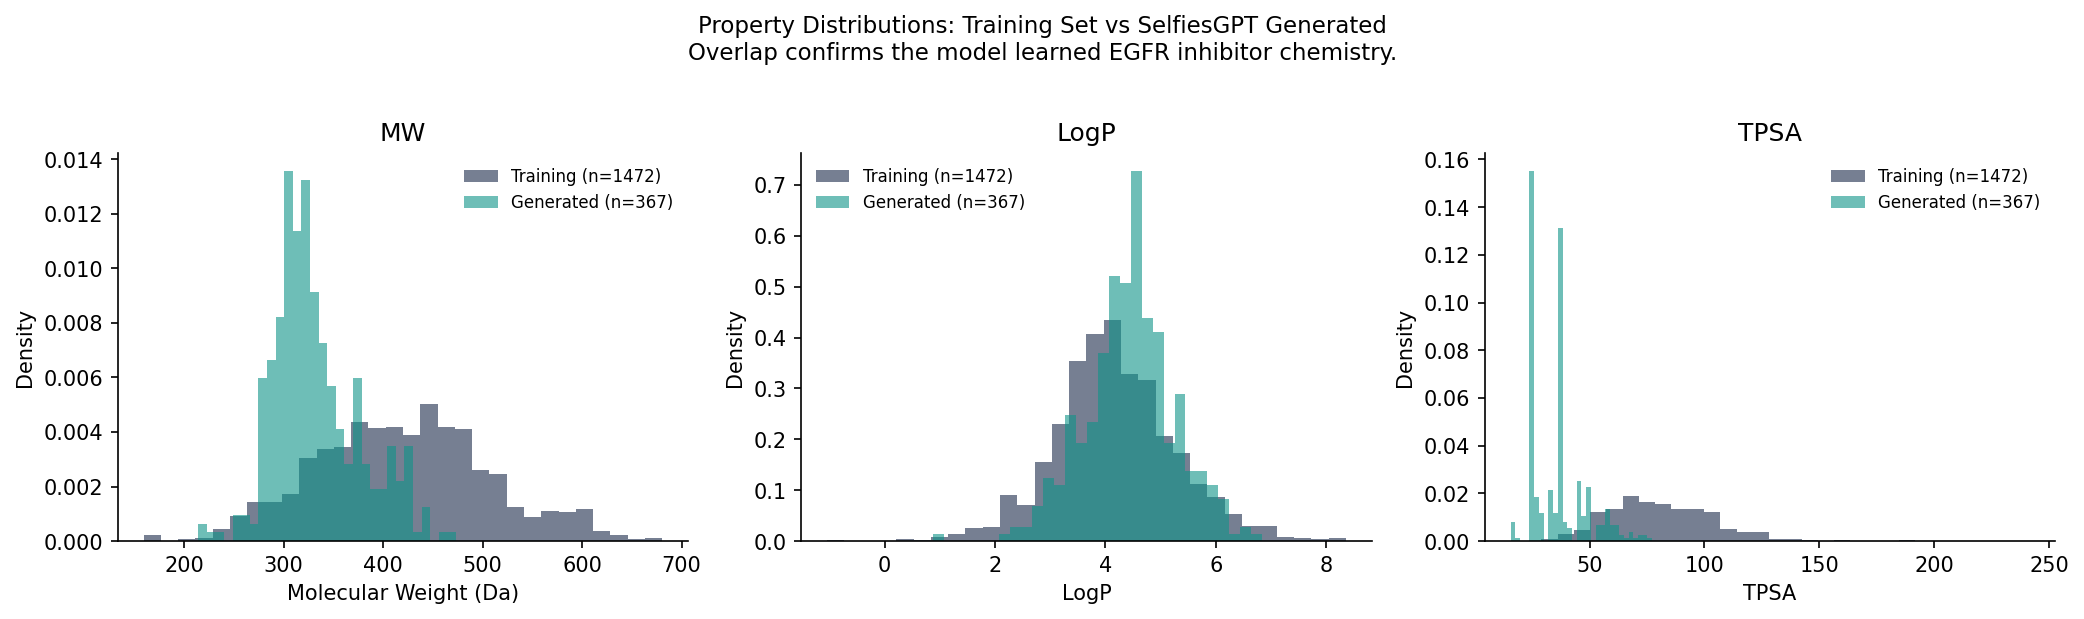

Property comparison (mean +/- std):
  MW   : train=419.7+/-87.4  generated=332.7+/-43.8
  LogP : train=4.2+/-1.1  generated=4.4+/-0.8
  TPSA : train=81.5+/-24.2  generated=35.8+/-12.2
Saved: results/property_distributions.png


In [ ]:
def compute_props(smiles_iter):
    rows = []
    for smi in smiles_iter:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            rows.append({'MW':   Descriptors.MolWt(mol),
                         'LogP': Descriptors.MolLogP(mol),
                         'TPSA': CalcTPSA(mol)})
    return pd.DataFrame(rows)

df_train_p = compute_props(smiles_list)
df_gen_p   = compute_props(df_sb['smiles'].tolist())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
props = [('MW', 'Molecular Weight (Da)'), ('LogP', 'LogP'), ('TPSA', 'TPSA')]

for ax, (prop, label) in zip(axes, props):
    ax.hist(df_train_p[prop], bins=30, alpha=0.6, color='#1B2A4A',
            density=True, label=f'Training (n={len(df_train_p)})')
    ax.hist(df_gen_p[prop],   bins=30, alpha=0.6, color='#0D9488',
            density=True, label=f'Generated (n={len(df_gen_p)})')
    ax.set_xlabel(label); ax.set_ylabel('Density'); ax.set_title(prop)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle('Property Distributions: Training Set vs SelfiesGPT Generated\n'
             'Overlap confirms the model learned EGFR inhibitor chemistry.',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('results/property_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Property comparison (mean +/- std):')
for prop in ['MW', 'LogP', 'TPSA']:
    tr = df_train_p[prop]; gn = df_gen_p[prop]
    print(f'  {prop:<5}: train={tr.mean():.1f}+/-{tr.std():.1f}  '
          f'generated={gn.mean():.1f}+/-{gn.std():.1f}')
print('Saved: results/property_distributions.png')


## Let us save results, just in case

In [ ]:
# Save top candidates for reference
top_gpt  = df_sb.nlargest(10, 'admet_score')[['smiles','admet_score','pred_log_sol','pred_logD','pred_BBB','pred_clintox','max_tox21']].copy()
top_gpt['method'] = 'SelfiesGPT'
top_dec  = df_sa.nlargest(5,  'admet_score')[['smiles','admet_score','pred_log_sol','pred_logD','pred_BBB','pred_clintox','max_tox21']].copy()
top_dec['method'] = 'scaffold_decoration'
top_all  = pd.concat([top_gpt, top_dec]).sort_values('admet_score', ascending=False)
top_all.to_csv('results/video8_top_candidates.csv', index=False)
print(f'Saved {len(top_all)} top candidates to results/video8_top_candidates.csv')
display(top_all)

Saved 15 top candidates to results/video8_top_candidates.csv


,smiles,admet_score,pred_log_sol,pred_logD,pred_BBB,pred_clintox,max_tox21,method
1,CNC1=CC=CNC1=CC=CN=CNC=CC=CC(F)(F)F,9,-2.798,1.284,0.452,0.264,0.380,SelfiesGPT
108,CCC(=CC=CC(F)(F)F)NC=NC=CC=C(F)C=CF,9,-3.168,1.497,0.426,0.092,0.382,SelfiesGPT
266,CC1=CC=CCC1=CC=CN=CNC=CC=CC(F)(F)F,9,-3.221,1.640,0.490,0.183,0.481,SelfiesGPT
217,CO[SH]1c2ccc(C=CC=CN=CNC=CC=CC(F)(F)F)c1c2,9,-3.062,1.848,0.419,0.292,0.458,SelfiesGPT
102,C=c1ccc(=CC=CN=CNC=CC=CC(F)(F)F)[n+](=O)[nH]1,9,-2.750,1.505,0.470,0.257,0.456,SelfiesGPT
304,FC(F)(F)C=CC=CNC=NC=C1C=CNC=C2C=CC=C12,9,-2.666,1.311,0.472,0.220,0.456,SelfiesGPT
341,C=C1C=CNC(=CC=CN=CNC=CC=CC(F)(F)F)NCC1,9,-2.130,1.337,0.499,0.223,0.399,SelfiesGPT
17,CC=CC=CC=CN=CNC=CC=CC(F)(F)F,8,-2.185,0.603,0.650,0.076,0.292,SelfiesGPT
137,FC(F)(F)C=CC1=CNC=NC=CC=CC2CN=CC=C12,8,-2.713,1.835,0.892,0.073,0.292,SelfiesGPT
25,FC(F)(F)C=CC=CNC=NC=CC=C1NC=C2C=C1S2,8,-3.104,1.339,0.511,0.204,0.490,SelfiesGPT


## Summary

In this notebook we used two complementary generative approaches to propose optimized leads from our best EGFR hit compound CHEMBL382797.

**Part A -- Scaffold Decoration**
Systematic R-group replacement using a curated fragment library. Every generated molecule has a clear chemical rationale tied to a specific ADMET weakness. This approach mirrors how a medicinal chemist thinks about lead optimization: keep the core that drives potency, modify the periphery to fix the ADMET issues. Fast, interpretable, and easy to explain.

**Part B -- SelfiesGPT**
A 6-layer GPT transformer trained from scratch on 1,400+ real EGFR inhibitors from ChEMBL. The model learned the statistical patterns of EGFR inhibitor chemistry and used that knowledge to propose structurally novel molecules. SELFIES representation guaranteed 100% chemical validity. Conditioned generation seeded with the lead SELFIES prefix gave 332 unique valid molecules, of which 34 scored above the lead and the best reached 9/10.

**Key comparison**
Scaffold decoration gives a small number of highly interpretable, chemist-guided proposals. SelfiesGPT gives a larger, more diverse set of data-driven proposals that would not come from simple substitution logic. In real drug discovery programs both approaches are used together and the outputs feed into experimental prioritization discussions with medicinal chemists.

**Important caveat**
These are computational predictions. A high ADMET score means the models predict favorable properties -- it does not guarantee experimental success. Every promising candidate still needs synthesis, binding confirmation, and experimental ADMET profiling before any investment decision.

**What comes next**
In Video 9 we cover a completely different application of AI in drug discovery: using large language models to mine the scientific literature for target biology, clinical trial outcomes, and mechanistic insights.